# 01 — Baselines
Dos modelos de referencia sin redes neuronales:
- **Naive**: predice el último retorno conocido (`X[:, -1, :]`)
- **Regresión lineal**: sklearn sobre X aplanado (igual que en clase)

Estos valores son el mínimo a superar con las redes neuronales.

In [14]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..', 'src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, yfinance as yf
warnings.simplefilter('ignore')
from sklearn.linear_model import LinearRegression

from utils import (TICKERS, INPUT_WINDOWS, OUTPUT_WINDOWS, RANDOM_SEED,
                   create_time_series_data, make_splits,
                   eval_mae_naive, plot_mae_matrix)

In [15]:
# Carga de datos (idéntico a 00_datos.ipynb)
precios = yf.download(TICKERS, start='1945-01-01', auto_adjust=True, progress=False)['Close']
precios.dropna(axis=1, inplace=True)
returns = np.log(precios).diff().dropna()
print(f'Retornos: {returns.shape}')

Retornos: (16194, 23)


## Bucle sobre las 16 combinaciones de ventanas

In [16]:
# Matrices de resultados: filas=V_in, columnas=V_out
shape = (len(INPUT_WINDOWS), len(OUTPUT_WINDOWS))
res = {m: {s: np.zeros(shape) for s in ['train','val','test']}
       for m in ['naive','lineal']}

for i, V_in in enumerate(INPUT_WINDOWS):
    for j, V_out in enumerate(OUTPUT_WINDOWS):
        X, y = create_time_series_data(returns, V_in, V_out)
        X_tr, X_v, X_ts, y_tr, y_v, y_ts = make_splits(X, y)

        # ── Naive forecast: último valor conocido ──────────────────────────
        res['naive']['train'][i,j] = eval_mae_naive(X_tr, y_tr)
        res['naive']['val'][i,j]   = eval_mae_naive(X_v,  y_v)
        res['naive']['test'][i,j]  = eval_mae_naive(X_ts, y_ts)

        # ── Regresión lineal sobre X aplanado (igual que en clase) ──────
        X_tr_f = X_tr.reshape(len(X_tr), -1)
        X_v_f  = X_v.reshape(len(X_v),  -1)
        X_ts_f = X_ts.reshape(len(X_ts), -1)

        lin = LinearRegression().fit(X_tr_f, y_tr)
        res['lineal']['train'][i,j] = np.mean(np.abs(lin.predict(X_tr_f) - y_tr))
        res['lineal']['val'][i,j]   = np.mean(np.abs(lin.predict(X_v_f)  - y_v))
        res['lineal']['test'][i,j]  = np.mean(np.abs(lin.predict(X_ts_f) - y_ts))

        print(f'V_in={V_in:2d}  V_out={V_out:2d}  '
              f'naive_test={res["naive"]["test"][i,j]:.4f}  '
              f'lineal_test={res["lineal"]["test"][i,j]:.4f}')

V_in= 5  V_out= 1  naive_test=0.0178  lineal_test=0.0124
V_in= 5  V_out= 5  naive_test=0.0137  lineal_test=0.0056
V_in= 5  V_out=30  naive_test=0.0125  lineal_test=0.0023
V_in= 5  V_out=90  naive_test=0.0122  lineal_test=0.0013
V_in=10  V_out= 1  naive_test=0.0178  lineal_test=0.0126
V_in=10  V_out= 5  naive_test=0.0137  lineal_test=0.0057
V_in=10  V_out=30  naive_test=0.0125  lineal_test=0.0024
V_in=10  V_out=90  naive_test=0.0122  lineal_test=0.0013
V_in=30  V_out= 1  naive_test=0.0178  lineal_test=0.0130
V_in=30  V_out= 5  naive_test=0.0137  lineal_test=0.0059
V_in=30  V_out=30  naive_test=0.0125  lineal_test=0.0024
V_in=30  V_out=90  naive_test=0.0122  lineal_test=0.0014
V_in=90  V_out= 1  naive_test=0.0178  lineal_test=0.0143
V_in=90  V_out= 5  naive_test=0.0137  lineal_test=0.0065
V_in=90  V_out=30  naive_test=0.0125  lineal_test=0.0027
V_in=90  V_out=90  naive_test=0.0122  lineal_test=0.0015


## Resultados — Naive forecast

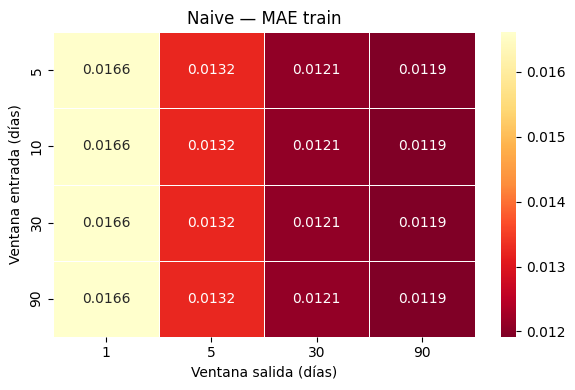

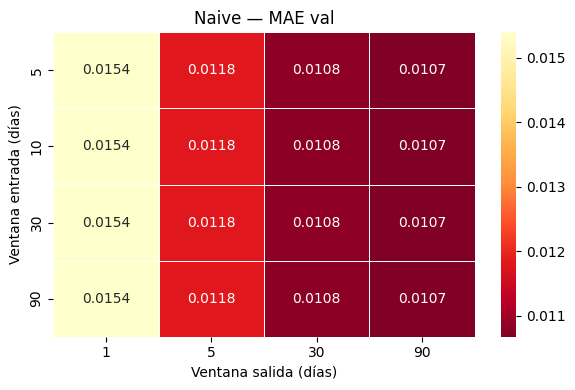

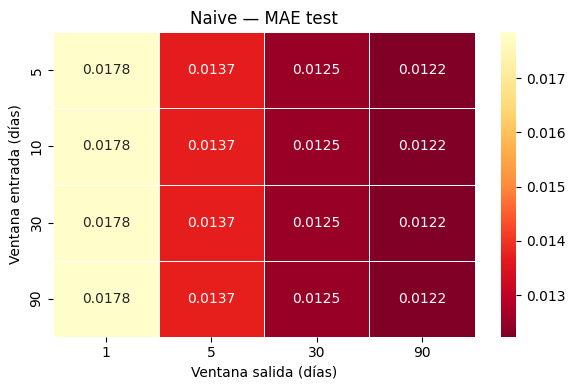

In [17]:
for split in ['train', 'val', 'test']:
    df = pd.DataFrame(res['naive'][split],
                      index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS)
    plot_mae_matrix(df, title=f'Naive — MAE {split}')

## Resultados — Regresión lineal

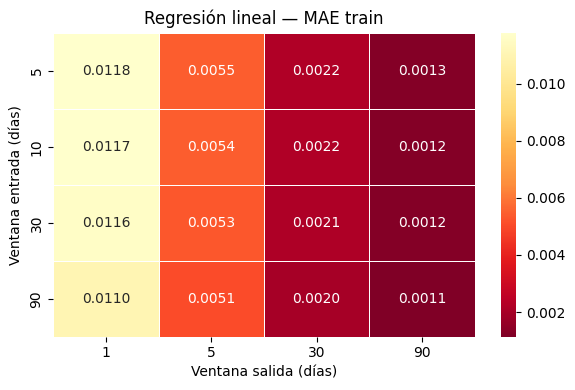

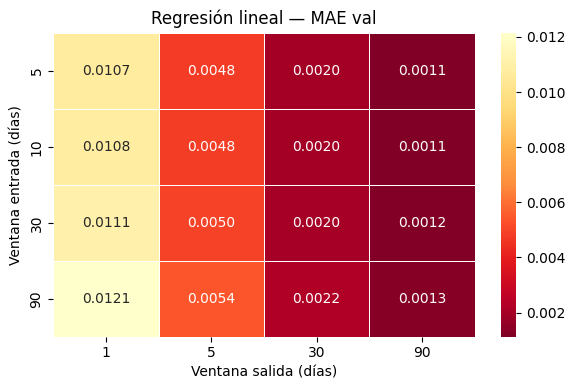

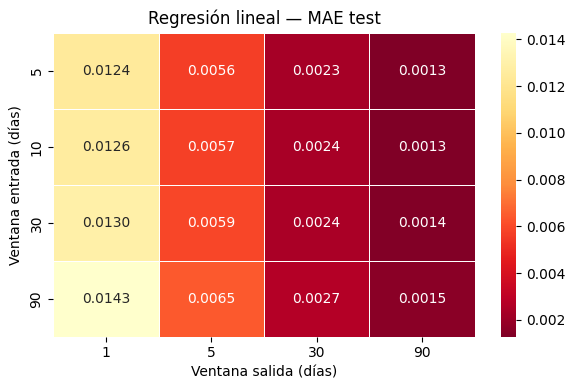

In [18]:
for split in ['train', 'val', 'test']:
    df = pd.DataFrame(res['lineal'][split],
                      index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS)
    plot_mae_matrix(df, title=f'Regresión lineal — MAE {split}')

## Tabla resumen — MAE en test (referencia para las redes neuronales)

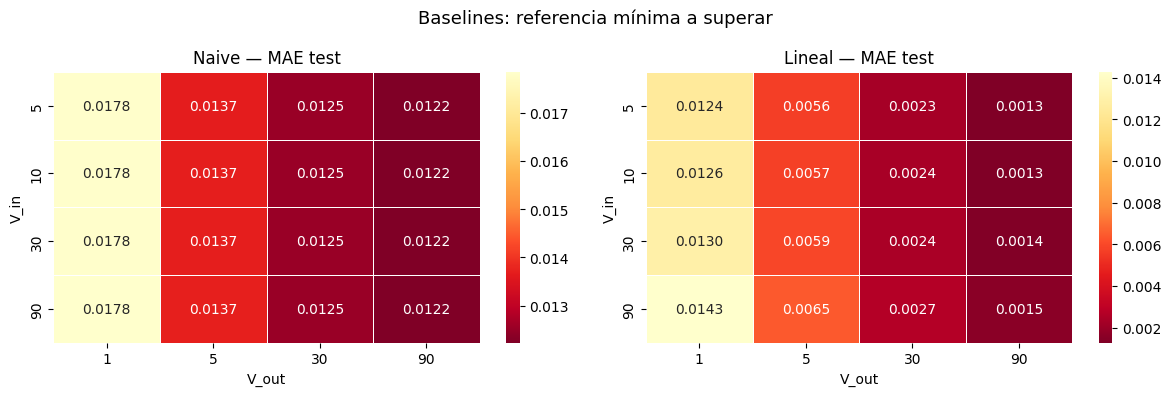

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, modelo in zip(axes, ['naive', 'lineal']):
    df = pd.DataFrame(res[modelo]['test'], index=INPUT_WINDOWS, columns=OUTPUT_WINDOWS)
    sns.heatmap(df.astype(float), annot=True, fmt='.4f',
                cmap='YlOrRd_r', ax=ax, linewidths=.5)
    ax.set_title(f'{modelo.capitalize()} — MAE test')
    ax.set_xlabel('V_out'); ax.set_ylabel('V_in')
plt.suptitle('Baselines: referencia mínima a superar', fontsize=13)
plt.tight_layout(); plt.show()

In [20]:
# Verificación: el gap val/test es estructural del split
print("Gap val→test (% relativo) — debe ser similar entre baselines y NN:")
for V_in in INPUT_WINDOWS:
    for V_out in OUTPUT_WINDOWS:
        i = INPUT_WINDOWS.index(V_in); j = OUTPUT_WINDOWS.index(V_out)
        gap_naive = (res['naive']['test'][i,j] - res['naive']['val'][i,j]) / res['naive']['val'][i,j] * 100
        gap_lin   = (res['lineal']['test'][i,j] - res['lineal']['val'][i,j]) / res['lineal']['val'][i,j] * 100
        print(f"V_in={V_in:2d} V_out={V_out:2d}  naive: {gap_naive:+.1f}%  lineal: {gap_lin:+.1f}%")

Gap val→test (% relativo) — debe ser similar entre baselines y NN:
V_in= 5 V_out= 1  naive: +15.7%  lineal: +16.2%
V_in= 5 V_out= 5  naive: +15.8%  lineal: +18.0%
V_in= 5 V_out=30  naive: +15.7%  lineal: +19.4%
V_in= 5 V_out=90  naive: +14.6%  lineal: +13.4%
V_in=10 V_out= 1  naive: +15.7%  lineal: +16.6%
V_in=10 V_out= 5  naive: +15.8%  lineal: +18.7%
V_in=10 V_out=30  naive: +15.8%  lineal: +19.9%
V_in=10 V_out=90  naive: +14.6%  lineal: +13.4%
V_in=30 V_out= 1  naive: +15.8%  lineal: +16.5%
V_in=30 V_out= 5  naive: +15.9%  lineal: +19.3%
V_in=30 V_out=30  naive: +15.7%  lineal: +21.5%
V_in=30 V_out=90  naive: +14.6%  lineal: +15.8%
V_in=90 V_out= 1  naive: +15.9%  lineal: +17.5%
V_in=90 V_out= 5  naive: +16.1%  lineal: +19.1%
V_in=90 V_out=30  naive: +15.9%  lineal: +20.4%
V_in=90 V_out=90  naive: +14.6%  lineal: +22.0%
